In [1]:
import numpy as np
import os
import pandas as pd
import xarray as xr
from glob import glob
import matplotlib.pyplot as plt
import itertools as it
from scipy.stats import linregress
from matplotlib.cm import get_cmap
from utils.constants import chamber_levels_complete
import matplotlib.ticker as ticker
import itertools as it
from matplotlib import rcParams
from matplotlib.colors import BoundaryNorm
from utils.analysis import uq_get_obs, uq_get_sim
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter

rcParams['font.size'] = 12
rcParams['axes.titlesize'] = 12

pft_names = ['Spruce', 'Tamarack', 'Shrub']

outdir = os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 'extract')

chambers_ordered = {
    'amb': ['7', '6', '20', '13', '8', '17'],
    'elev': ['19', '11', '4', '16', '10']
}

xticklabels = ['TAMB', 'T0.00', 'T2.25','T4.50', 'T6.75', 'T9.00', 
               'T0.00CO2', 'T2.25CO2', 'T4.5CO2', 'T6.75CO2', 'T9.00CO2']
labs = 'abcdefghijklmnopqrstuvwxyz'

In [2]:
#########################################################################
# Read the N & P uptake fractions from optimal models
#########################################################################
collection_gs = {}
collection_annual = {}

for prefix in ['20231116', 'UQ_20231118', 'UQ_20240107', 'UQ_20240112']:
    temp_data = pd.read_csv(os.path.join(outdir, prefix, 'analysis_ts.csv'),
                                         header = [0, 1, 2, 3], index_col = 0, parse_dates=True)

    # restrict BTRAN & ZWT to growing season
    for col in temp_data.columns:
        if col[1] in ['BTRAN','ZWT']:
            temp_data.loc[(temp_data.index.month < 5) | (temp_data.index.month > 10), col] = np.nan

    # ratio of total nutrient uptake to AVAILC

    # average hummock and hollow, resample to annual
    temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1
        ).apply(lambda df: df.iloc[:,0] * 0.64 + df.iloc[:,1] * 0.36)

    ## ~~Restrict all to growing season
    ## ~~filt = (temp_data.index.month >= 5) & (temp_data.index.month <= 10)
    # No, use whole year!
    filt = (temp_data.index.month >= 1) & (temp_data.index.month <= 12)
    # Limit to < 2021 to be consistent with Paul's data
    filt = filt & (temp_data.index.year <= 2021)
    collection_gs[prefix] = temp_data.loc[filt, :]

    temp_annual = temp_data.resample('1Y').mean()
    temp_annual.index = temp_annual.index.year
    temp_annual.columns = temp_annual.columns.reorder_levels(['variable', 'pft', 'plot'])
    temp_annual = temp_annual.stack()
    collection_annual[prefix] = temp_data

/tmp/ipykernel_1064084/569602404.py:19: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1
/tmp/ipykernel_1064084/569602404.py:30: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  temp_annual = temp_data.resample('1Y').mean()
/tmp/ipykernel_1064084/569602404.py:33: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  temp_annual = temp_annual.stack()
/tmp/ipykernel_1064084/569602404.py:19: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1
/tmp/ipykernel_1064084/569602404.py:30: FutureWar

In [3]:
#########################################################################
# Read the N & P uptake fractions from modified model ensembles
#########################################################################
subset_ensemble = {'UQ_20240107': [249,2702,61,936,174,1535,1485,1002,3119,1741,2263,1081,1590,103,
                       1918,2786,2541,1532,559,1685,902,1026,1392,1881,1377,316,722,1069,
                       1957,131,1198,1027,616,2120,1963,3384,3510,1847,653,3203],
                   'UQ_20240112': [1944,2204,1429,2540,2764,867,654,1870,1079,1362,2922,1330,
                                   448,2364,
                       2601,2165,2421,3609,3554,34,1172,1480,161,1980,2259,840,3116,1071,
                       3744,1372,2495,2096,3204,55,3726,3297,2971,1838,1002,3650]}

index = pd.MultiIndex.from_product([['N','P'], ['Spruce','Tamarack','Shrub'],
                                    ['min froot','min fungi','org fungi'], 
                                    ['p0','p25','p50','p75','p100']])
collection = {}
for PREFIX in subset_ensemble.keys():
    N = len(subset_ensemble[PREFIX])
    BLOCK = 10
    niter = int(N / BLOCK)
    data = np.full([N, 11, 18], np.nan)
    for b in range(niter):
        temp = np.load(os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 
                                    'extract', PREFIX, f'ensemble_fungifrac_raw_part{b:03g}.bin'),
                       allow_pickle=True)
        data[(b*BLOCK):((b+1)*BLOCK), :, :] = temp

    data = np.nanpercentile(data, axis = 0, q = [0, 25, 50, 75, 100])

    # unit: gN m-2 year-1; PFT area space
    collection[PREFIX] = pd.DataFrame(np.nan, columns = index, 
                                      index = chambers_ordered['amb'] + chambers_ordered['elev'])
    for n, plot in enumerate(collection[PREFIX].index):
        for q, qtext in enumerate(['p0','p25','p50','p75','p100']):
            collection[PREFIX].loc[plot, (slice(None), slice(None), slice(None), qtext)] = \
                data[q, n, :]

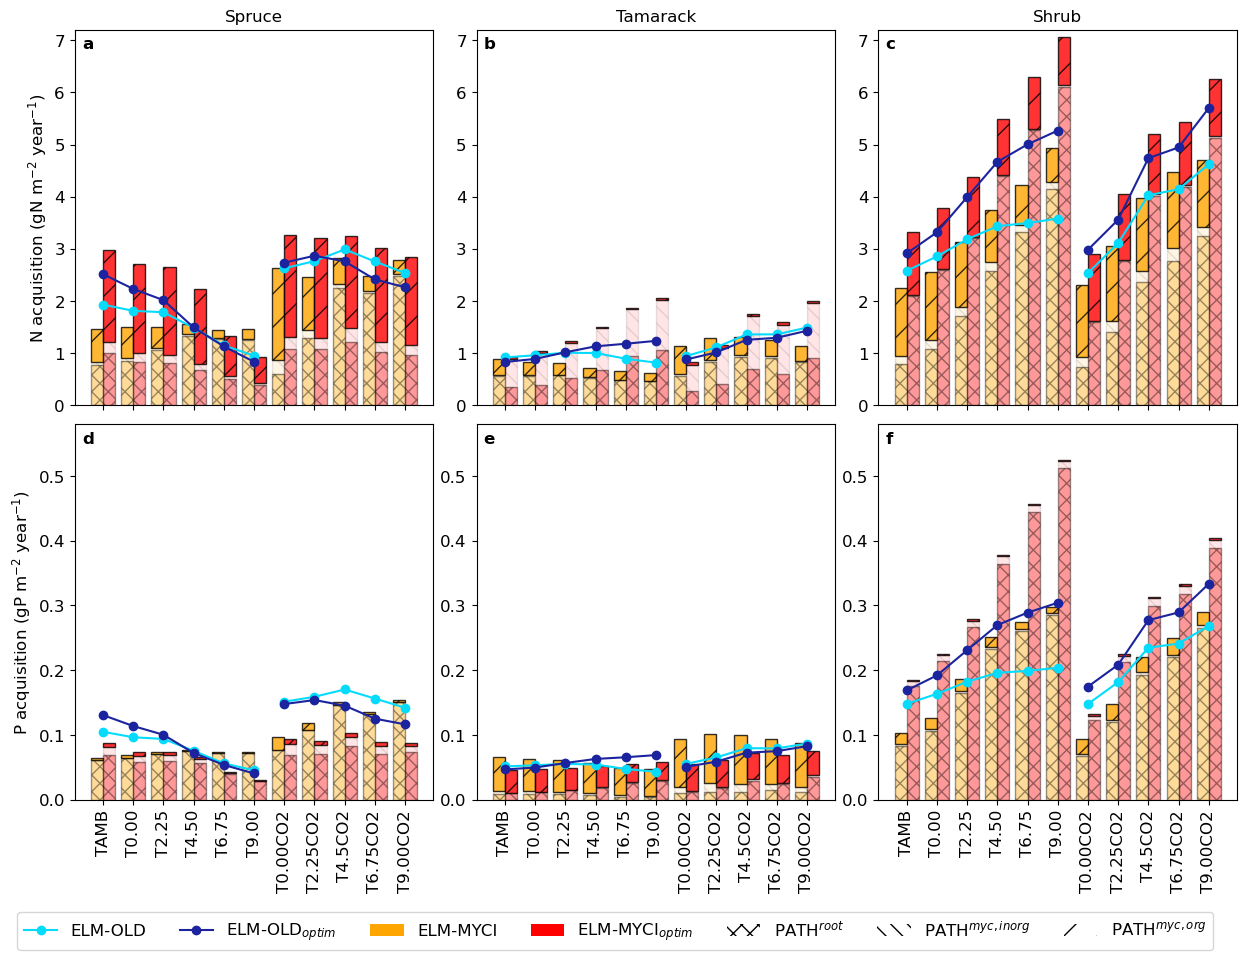

In [4]:
#########################################################################
# Make the graphics - optimized ensembles
#########################################################################
pft_frac = [0.36, 0.14, 0.25, 0.25]
fig, axes = plt.subplots(2, 3, figsize = (15, 10), sharex = True)
fig.subplots_adjust(hspace = 0.05, wspace = 0.12)
for n, nu in enumerate(['N','P']):
    for j, (pft, pftname) in enumerate(zip(['2','3','11'], pft_names)):
        ax = axes[n, j]

        # Default model
        temp = collection_gs['20231116'].mean(axis = 0).unstack().unstack( \
            ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
        froot_min = temp.loc[:, (pft, f'SMIN{nu}_TO_{nu}POOL')] * 86400 * 365 * pft_frac[j]
        # break between aCO2 and eCO2
        len_amb = len(chambers_ordered['amb'])
        h1, = ax.plot(range(len_amb), froot_min[:len_amb], '-o', color = '#05dbfc')
        ax.plot(range(len_amb, len(froot_min)), froot_min[len_amb:], '-o', color = '#05dbfc')

        # Default model, optimal parameter
        temp = collection_gs['UQ_20231118'].mean(axis = 0).unstack().unstack( \
            ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
        froot_min = temp.loc[:, (pft, f'SMIN{nu}_TO_{nu}POOL')] * 86400 * 365 * pft_frac[j]
        h2, = ax.plot(range(len_amb), froot_min[:len_amb], '-o', color = '#1b249e')
        ax.plot(range(len_amb, len(froot_min)), froot_min[len_amb:], '-o', color = '#1b249e')

        # Ensemble simulations
        h = [None, None]
        h3 = [None, None, None]
        for i, (prefix, color, name) in enumerate(
            zip(['UQ_20240107', 'UQ_20240112'], ['#ffa500', '#ff0000'],
                ['ELM-MYCI', 'ELM-MYCI$_{optim}$'])):
            temp = collection_gs[prefix].mean(axis = 0).unstack().unstack( \
                ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
            froot_min = temp.loc[:, (pft, f'SMIN{nu}_TO_{nu}POOL')] / \
                temp.loc[:, (pft, f'PLANT_{nu}DEMAND_POT')] * \
                temp.loc[:, (pft, f'FROOT_{nu}DEMAND_POT')]
            fungi_min = temp.loc[:, (pft, f'SMIN{nu}_TO_{nu}POOL')] / \
                temp.loc[:, (pft, f'PLANT_{nu}DEMAND_POT')] * \
                temp.loc[:, (pft, f'FUNGI_{nu}DEMAND_POT')]
            fungi_som = temp.loc[:, (pft, f'FUNGI_SOM_TO_{nu}POOL')]
            retemp = pd.concat([froot_min, fungi_min, fungi_som], axis = 1) * 86400 * 365 \
                               * pft_frac[j]
            retemp.columns = ['PATH$^{root}$', 'PATH$^{myc,inorg}$', 'PATH$^{myc,org}$']
            hatches = ['xx', '\\\\', '/']
            alphas = [0.4, 0.1, 0.8]

            bottom = np.zeros(retemp.shape[0])
            for c, col in enumerate(retemp.columns):
                temp = ax.bar(height = retemp[col].values, 
                              bottom = bottom,
                              x = np.arange(retemp.shape[0]), width = (2*np.mod(i,2)-1) * 0.4, 
                              facecolor = color, alpha = alphas[c], edgecolor = 'k',
                              align = 'edge')
                for bar in temp:
                    bar.set_hatch(hatches[c])
                bottom = bottom + retemp[col].values

            h[i] = ax.bar(np.nan, np.nan, facecolor = color)
            for c in range(3):
                h3[c] = ax.bar(np.nan, np.nan, facecolor = 'none')
                for bar in h3[c]:
                    bar.set_hatch(hatches[c])

        if n == 0:
            ax.set_title(pftname)
        if j == 0:
            ax.set_ylabel(f'{nu} acquisition (g{nu} m' + '$^{-2}$ year$^{-1}$)')
        ax.set_xticks(np.arange(collection[PREFIX].shape[0]))
        ax.set_xticklabels(xticklabels, rotation = 90)
        ax.text(0.02, 0.95, labs[n*3+j], fontdict = {'weight': 'bold'}, transform = ax.transAxes)

        if nu == 'N':
            ax.set_ylim([0, 7.2])
        else:
            ax.set_ylim([0, 0.58])
ax.legend([h1, h2] + h + h3, ['ELM-OLD', 'ELM-OLD$_{optim}$', 'ELM-MYCI', 'ELM-MYCI$_{optim}$'] + \
          list(retemp.columns), ncol = 7, loc = [-2.4, -0.4])

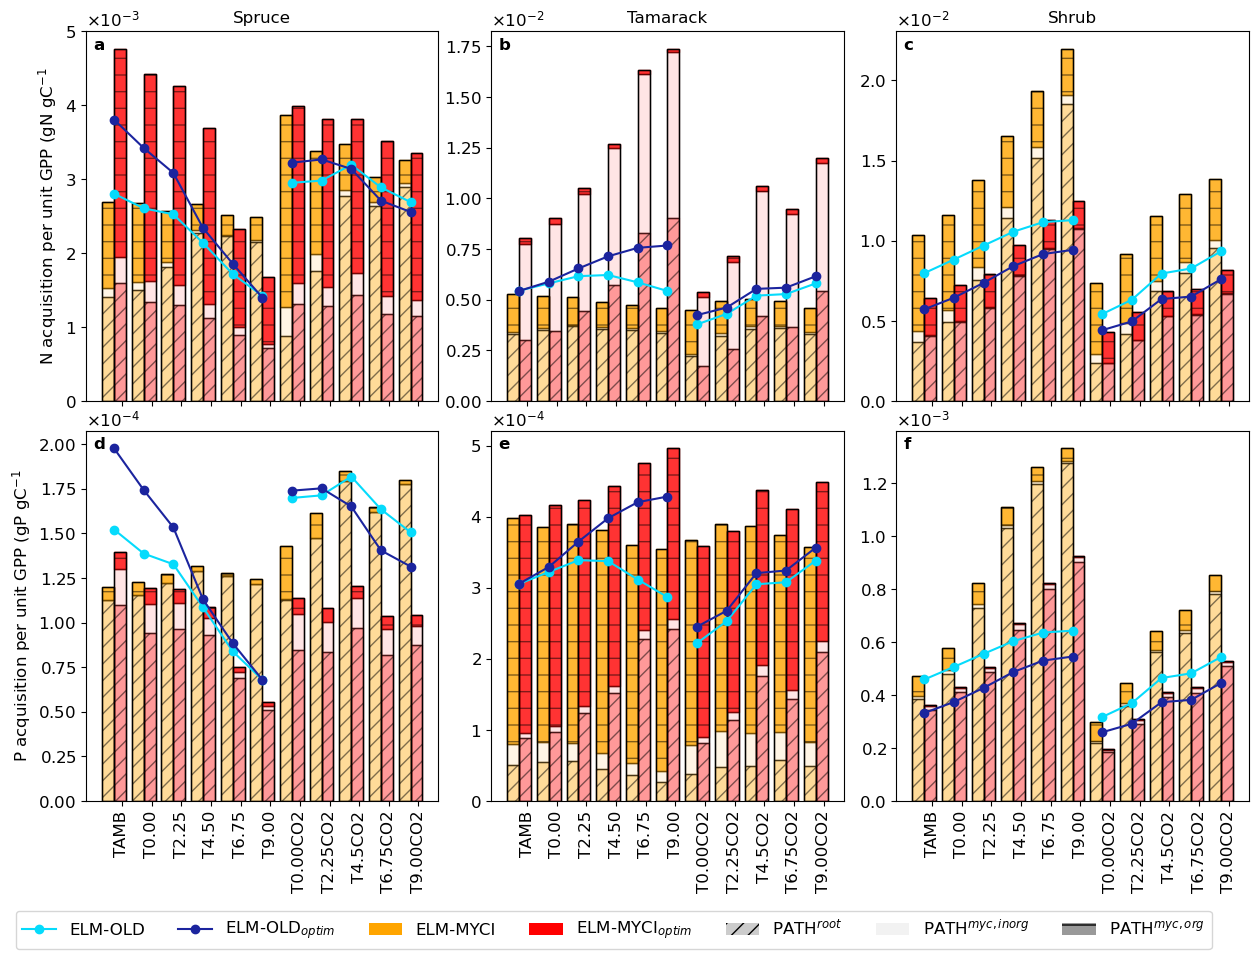

In [5]:
#########################################################################
# Make the graphics - optimized ensembles
# Plot on per unit GPP basis instead
#########################################################################
pft_frac = [0.36, 0.14, 0.25, 0.25]
fig, axes = plt.subplots(2, 3, figsize = (15, 10), sharex = True)
fig.subplots_adjust(hspace = 0.08, wspace = 0.15)
for n, nu in enumerate(['N','P']):
    for j, (pft, pftname) in enumerate(zip(['2','3','11'], pft_names)):
        ax = axes[n, j]

        # Default model
        temp = collection_gs['20231116'].mean(axis = 0).unstack().unstack( \
            ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
        froot_min = temp.loc[:, (pft, f'SMIN{nu}_TO_{nu}POOL')] * 86400 * 365 * pft_frac[j]
        froot_min = froot_min / (temp.loc[:, (pft, 'GPP')] * 86400 * 365 * pft_frac[j])
        # break between aCO2 and eCO2
        len_amb = len(chambers_ordered['amb'])
        h1, = ax.plot(range(len_amb), froot_min[:len_amb], '-o', color = '#05dbfc')
        ax.plot(range(len_amb, len(froot_min)), froot_min[len_amb:], '-o', color = '#05dbfc')

        # Default model, optimal parameter
        temp = collection_gs['UQ_20231118'].mean(axis = 0).unstack().unstack( \
            ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
        froot_min = temp.loc[:, (pft, f'SMIN{nu}_TO_{nu}POOL')] * 86400 * 365 * pft_frac[j]
        froot_min = froot_min / (temp.loc[:, (pft, 'GPP')] * 86400 * 365 * pft_frac[j])
        h2, = ax.plot(range(len_amb), froot_min[:len_amb], '-o', color = '#1b249e')
        ax.plot(range(len_amb, len(froot_min)), froot_min[len_amb:], '-o', color = '#1b249e')

        # Ensemble simulations
        h = [None, None]
        h3 = [None, None, None]
        for i, (prefix, color, name) in enumerate(
            zip(['UQ_20240107', 'UQ_20240112'], ['#ffa500', '#ff0000'],
                ['E-NU', 'E-NU$_{optim}$'])):
            temp = collection_gs[prefix].mean(axis = 0).unstack().unstack( \
                ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
            froot_min = temp.loc[:, (pft, f'SMIN{nu}_TO_{nu}POOL')] / \
                temp.loc[:, (pft, f'PLANT_{nu}DEMAND_POT')] * \
                temp.loc[:, (pft, f'FROOT_{nu}DEMAND_POT')]
            fungi_min = temp.loc[:, (pft, f'SMIN{nu}_TO_{nu}POOL')] / \
                temp.loc[:, (pft, f'PLANT_{nu}DEMAND_POT')] * \
                temp.loc[:, (pft, f'FUNGI_{nu}DEMAND_POT')]
            fungi_som = temp.loc[:, (pft, f'FUNGI_SOM_TO_{nu}POOL')]
            retemp = pd.concat([froot_min, fungi_min, fungi_som], axis = 1) * 86400 * 365 \
                               * pft_frac[j]
            retemp.columns = ['PATH$^{root}$', 'PATH$^{myc,inorg}$', 'PATH$^{myc,org}$']
            hatches = ['//', '', '-']
            alphas = [0.4, 0.1, 0.8]

            for col in retemp.columns:
                retemp[col] = retemp[col] / (temp.loc[:, (pft, 'GPP')] * 86400 * 365 * pft_frac[j])

            bottom = np.zeros(retemp.shape[0])
            for c, col in enumerate(retemp.columns):
                temp = ax.bar(height = retemp[col].values, 
                              bottom = bottom,
                              x = np.arange(retemp.shape[0]), width = (2*np.mod(i,2)-1) * 0.4, 
                              facecolor = color, alpha = alphas[c], edgecolor = color,
                              align = 'edge')

                temp = ax.bar(height = retemp[col].values, 
                              bottom = bottom,
                              x = np.arange(retemp.shape[0]), width = (2*np.mod(i,2)-1) * 0.4, 
                              facecolor = 'none', alpha = 0.5, edgecolor = 'k',
                              align = 'edge')
                for bar in temp:
                    bar.set_hatch(hatches[c])

                bottom = bottom + retemp[col].values
            ax.bar(height = retemp.sum(axis = 1).values, # wrapper
                   x = np.arange(retemp.shape[0]), width = (2*np.mod(i,2)-1) * 0.4, 
                   facecolor = 'none', edgecolor = 'k',
                   align = 'edge')

            h[i] = ax.bar(np.nan, np.nan, facecolor = color)
            for c in range(3):
                h3[c] = ax.bar(np.nan, np.nan, facecolor = 'grey', alpha = alphas[c])
                for bar in h3[c]:
                    bar.set_hatch(hatches[c])

        if n == 0:
            ax.set_title(pftname)
        if j == 0:
            ax.set_ylabel(f'{nu} acquisition per unit GPP (g{nu} gC' + '$^{-1}$')
        ax.set_xticks(np.arange(collection[PREFIX].shape[0]) + 0.8/3)
        ax.set_xticklabels(xticklabels, rotation = 90)
        ax.text(0.02, 0.95, labs[n*3+j], fontdict = {'weight': 'bold'}, transform = ax.transAxes)
        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

ax.legend([h1, h2] + h + h3, ['ELM-OLD', 'ELM-OLD$_{optim}$', 'ELM-MYCI', 'ELM-MYCI$_{optim}$'] + \
          list(retemp.columns), ncol = 7, loc = [-2.5, -0.4])

/tmp/ipykernel_1064084/62299230.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  temp = collection[PREFIX].loc[:, (nu, pftname, val)] * pft_frac[j] * 365
/tmp/ipykernel_1064084/62299230.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  temp = collection[PREFIX].loc[:, (nu, pftname, val)] * pft_frac[j] * 365
/tmp/ipykernel_1064084/62299230.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  temp = collection[PREFIX].loc[:, (nu, pftname, val)] * pft_frac[j] * 365
/tmp/ipykernel_1064084/62299230.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  temp = collection[PREFIX].loc[:, (nu, pftname, val)] * pft_frac[j] * 365
/tmp/ipykernel_1064084/62299230.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  temp = collection[PREFIX].loc[:, (nu, pftname, val)] * pft_frac[j] * 365
/tmp/ipykernel_1064084/62299230.py:30: PerformanceWarning: indexing pa

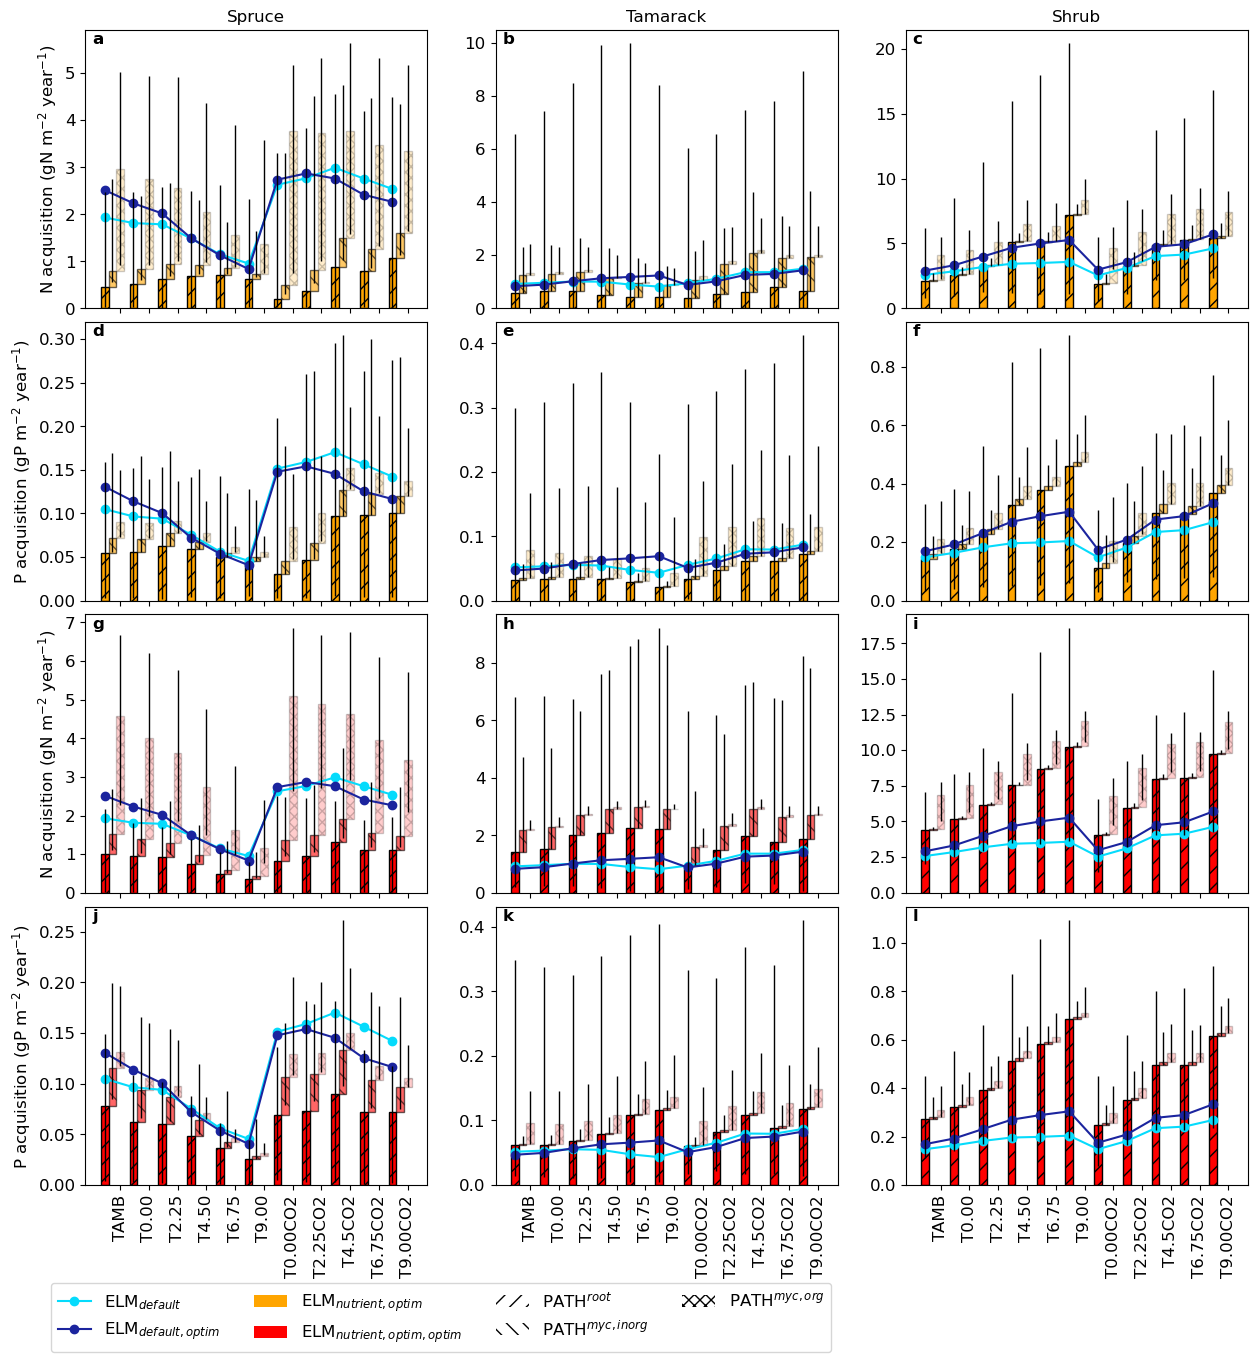

In [6]:
#########################################################################
# Make the graphics - all ensemble members
#########################################################################
pft_frac = [0.36, 0.14, 0.25, 0.25]
fig, axes = plt.subplots(4, 3, figsize = (15, 15), sharex = True)
fig.subplots_adjust(hspace = 0.05)
for u, (PREFIX, color, name) in enumerate(
    zip(['UQ_20240107', 'UQ_20240112'], ['#ffa500', '#ff0000'],
        ['E-NU', 'E-NU$_{optim}'])):
    for n, nu in enumerate(['N','P']):
        for j, (pft, pftname) in enumerate(zip(['2','3','11'], pft_names)):
            ax = axes[n+u*2, j]

            # Default model
            temp = collection_gs['20231116'].mean(axis = 0).unstack().unstack( \
                ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
            froot_min = temp.loc[:, (pft, f'SMIN{nu}_TO_{nu}POOL')] * 86400 * 365 * pft_frac[j]
            h1, = ax.plot(range(len(froot_min)), froot_min, '-o', color = '#05dbfc')

            temp = collection_gs['UQ_20231118'].mean(axis = 0).unstack().unstack( \
                ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
            froot_min = temp.loc[:, (pft, f'SMIN{nu}_TO_{nu}POOL')] * 86400 * 365 * pft_frac[j]
            h2, = ax.plot(range(len(froot_min)), froot_min, '-o', color = '#1b249e')

            # Ensemble simulations
            bottom = np.zeros(collection[PREFIX].shape[0])
            hatches = ['//', '\\\\', 'xxx']
            for p, (val, hatch) in enumerate(zip(['min froot', 'min fungi', 'org fungi'], hatches)):
                # convert from patch area to plot area
                temp = collection[PREFIX].loc[:, (nu, pftname, val)] * pft_frac[j] * 365
                median = temp.values[:, 2]
                yerr = np.vstack(
                    [median - temp.values[:, 0], temp.values[:, -1] - median]
                )
                xpos = np.arange(collection[PREFIX].shape[0]) + 0.8*p/3
                # plot the height
                h = ax.bar(height = median, bottom = bottom, 
                           x = xpos, facecolor = color, width = 0.8/3, 
                           alpha = (1-p/2.5), edgecolor = 'k')
                for bar in h:
                    bar.set_hatch(hatch)
                # plot the errorbar
                ax.errorbar(x = xpos, y = bottom + median, yerr = yerr, lw = 0, elinewidth=1, 
                            ecolor = 'k')
                bottom = bottom + median

            if u == 0:
                h3 = ax.bar(np.nan, np.nan, facecolor = color)
            else:
                h4 = ax.bar(np.nan, np.nan, facecolor = color)
            h5 = [None] * 3
            for c in range(3):
                h5[c] = ax.bar(np.nan, np.nan, facecolor = 'none')
                for bar in h5[c]:
                    bar.set_hatch(hatches[c])

            if (u == 0) & (n == 0):
                ax.set_title(pftname)
            if j == 0:
                ax.set_ylabel(f'{nu} acquisition (g{nu} m' + '$^{-2}$ year$^{-1}$)')
            ax.set_xticks(np.arange(collection[PREFIX].shape[0]) + 0.8*p/3)
            ax.set_xticklabels(xticklabels, rotation = 90)
            ax.text(0.02, 0.95, labs[u*6+n*3+j], fontdict = {'weight': 'bold'}, 
                    transform = ax.transAxes)
ax.legend([h1, h2, h3, h4] + h5, 
          ['ELM$_{default}$', 'ELM$_{default,optim}$', 'ELM$_{nutrient,optim}$', 'ELM$_{nutrient,optim,optim}$'] + \
          ['PATH$^{root}$', 'PATH$^{myc,inorg}$', 'PATH$^{myc,org}$'], ncol = 4, loc = [-2.5, -0.6])

/tmp/ipykernel_1064084/221806436.py:22: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  sminn = sminn.resample('1Y').mean()
/tmp/ipykernel_1064084/221806436.py:31: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  min_cpool = smin_uptake.resample('1Y').mean() / cdemand.resample('1Y').mean().values


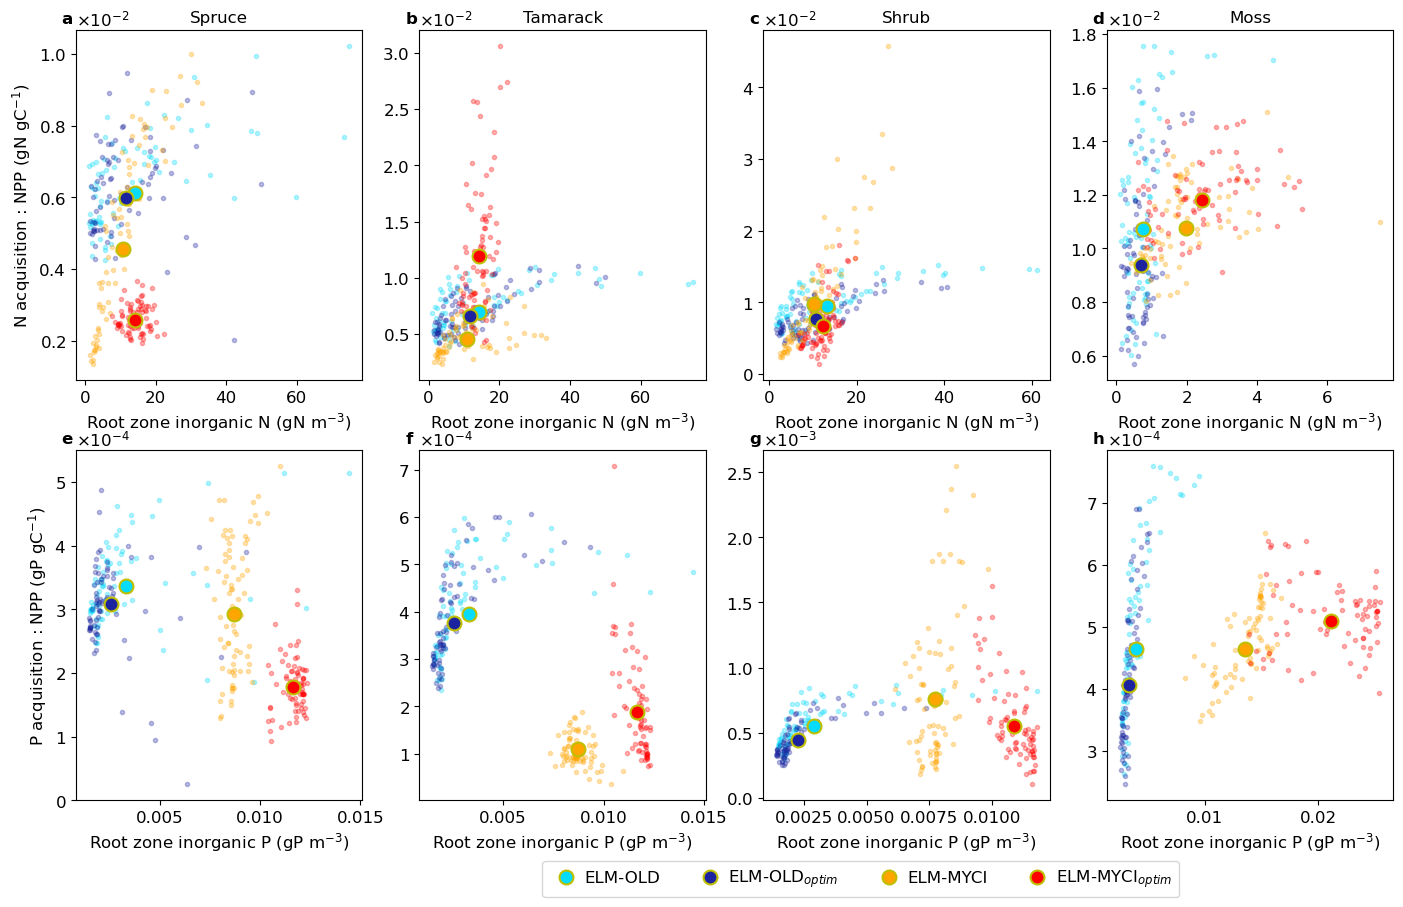

In [7]:
#########################################################################
# N&P uptake per unit GPP, across temperature and nutrient gradients
#########################################################################
fig, axes = plt.subplots(2, 4, figsize = (17, 10), sharex = False, sharey = False)
for j, nu in enumerate(['N','P']):
    if nu == 'N':
        nu_var = 'SMINN_vr_ROOTFR'
    else:
        nu_var = 'SOLUTIONP_vr_ROOTFR'

    for i, (pft,name) in enumerate(zip(['2','3','11','12'],
                                        ['Spruce','Tamarack','Shrub','Moss'])):
        ax = axes[j, i]

        for prefix, pname, colr in zip(
            ['20231116', 'UQ_20231118', 'UQ_20240107', 'UQ_20240112'],  
            ['ELM-OLD', 'ELM-OLD$_{optim}$', 'ELM-MYCI', 'ELM-MYCI$_{optim}$'], 
            ['#05dbfc', '#1b249e', '#ffa500', '#ff0000']):

            # Soil mineral nutrients content
            sminn = collection_gs[prefix].loc[:, (slice(None), nu_var, pft)]
            sminn = sminn.resample('1Y').mean()
            sminn_mean = sminn.mean().mean()

            # C assimilation
            cdemand = collection_gs[prefix].loc[:, (slice(None), 'AVAILC', pft)]

            # Total mineral nutrients uptake
            smin_uptake = collection_gs[prefix].loc[:, (slice(None), 
                                                        f'SMIN{nu}_TO_{nu}POOL', pft)]
            min_cpool = smin_uptake.resample('1Y').mean() / cdemand.resample('1Y').mean().values
            min_cpool_mean = smin_uptake.mean().mean() / cdemand.mean().mean()

            # Draw
            h = ax.plot(sminn.values.reshape(-1), (min_cpool).values.reshape(-1), 'o',
                        color = colr, markersize = 3, alpha = 0.3, zorder = 1)
            ax.plot(sminn_mean, min_cpool_mean, 'o',
                    color = colr, markersize = 10, markeredgecolor = 'y',
                    zorder = 3, markeredgewidth = 1.5, label = pname)

        if i == 0:
            if nu == 'N':
                ax.set_ylabel(f'{nu} acquisition : NPP (g' + nu + ' gC$^{-1}$)')
            else:
                ax.set_ylabel(f'{nu} acquisition : NPP (g' + nu + ' gC$^{-1}$)')

        if j == 0:
            ax.set_title(name)

        if nu == 'N':
            ax.set_xlabel(f'Root zone inorganic {nu} (g{nu} ' + 'm$^{-3}$)')
        else:
            ax.set_xlabel(f'Root zone inorganic {nu} (g' + f'{nu} ' + 'm$^{-3}$)')
        #ax.set_xscale('log')
        #ax.set_yscale('log')
        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        ax.text(-0.05, 1.02, labs[j*4+i], fontdict = {'weight': 'bold'}, transform = ax.transAxes)

ax.legend(ncol = 4, handletextpad = 0.1, loc = 'upper left',
          bbox_to_anchor = (-2, -0.15))


/tmp/ipykernel_1064084/4237687849.py:23: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  sminn = sminn.resample('1Y').mean()
/tmp/ipykernel_1064084/4237687849.py:32: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  min_cpool = smin_uptake.resample('1Y').mean() / cdemand.resample('1Y').mean().values


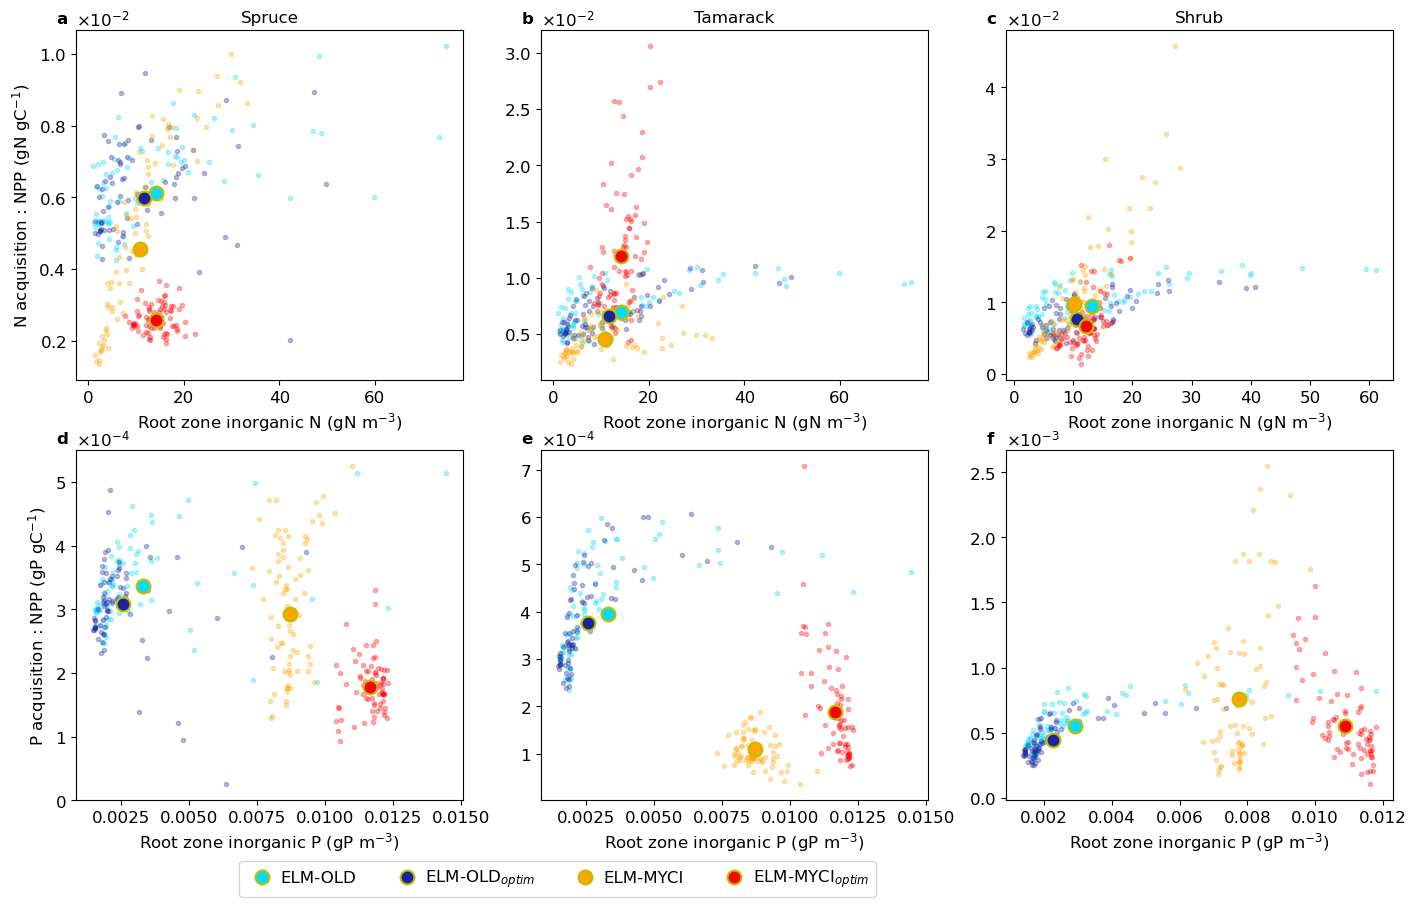

In [8]:
#########################################################################
# N&P uptake per unit GPP, across temperature and nutrient gradients
# Skip moss
#########################################################################
fig, axes = plt.subplots(2, 3, figsize = (17, 10), sharex = False, sharey = False)
for j, nu in enumerate(['N','P']):
    if nu == 'N':
        nu_var = 'SMINN_vr_ROOTFR'
    else:
        nu_var = 'SOLUTIONP_vr_ROOTFR'

    for i, (pft,name) in enumerate(zip(['2','3','11'],
                                        ['Spruce','Tamarack','Shrub'])):
        ax = axes[j, i]

        for prefix, pname, colr in zip(
            ['20231116', 'UQ_20231118', 'UQ_20240107', 'UQ_20240112'],  
            ['ELM-OLD', 'ELM-OLD$_{optim}$', 'ELM-MYCI', 'ELM-MYCI$_{optim}$'], 
            ['#05dbfc', '#1b249e', '#ffa500', '#ff0000']):

            # Soil mineral nutrients content
            sminn = collection_gs[prefix].loc[:, (slice(None), nu_var, pft)]
            sminn = sminn.resample('1Y').mean()
            sminn_mean = sminn.mean().mean()

            # C assimilation
            cdemand = collection_gs[prefix].loc[:, (slice(None), 'AVAILC', pft)]

            # Total mineral nutrients uptake
            smin_uptake = collection_gs[prefix].loc[:, (slice(None), 
                                                        f'SMIN{nu}_TO_{nu}POOL', pft)]
            min_cpool = smin_uptake.resample('1Y').mean() / cdemand.resample('1Y').mean().values
            min_cpool_mean = smin_uptake.mean().mean() / cdemand.mean().mean()

            # Draw
            h = ax.plot(sminn.values.reshape(-1), (min_cpool).values.reshape(-1), 'o',
                        color = colr, markersize = 3, alpha = 0.3, zorder = 1)
            ax.plot(sminn_mean, min_cpool_mean, 'o',
                    color = colr, markersize = 10, markeredgecolor = 'y',
                    zorder = 3, markeredgewidth = 1.5, label = pname)

        if i == 0:
            if nu == 'N':
                ax.set_ylabel(f'{nu} acquisition : NPP (g' + nu + ' gC$^{-1}$)')
            else:
                ax.set_ylabel(f'{nu} acquisition : NPP (g' + nu + ' gC$^{-1}$)')

        if j == 0:
            ax.set_title(name)

        if nu == 'N':
            ax.set_xlabel(f'Root zone inorganic {nu} (g{nu} ' + 'm$^{-3}$)')
        else:
            ax.set_xlabel(f'Root zone inorganic {nu} (g' + f'{nu} ' + 'm$^{-3}$)')
        #ax.set_xscale('log')
        #ax.set_yscale('log')
        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        ax.text(-0.05, 1.02, labs[j*3+i], fontdict = {'weight': 'bold'}, transform = ax.transAxes)

ax.legend(ncol = 4, handletextpad = 0.1, loc = 'upper left',
          bbox_to_anchor = (-2, -0.15))


/tmp/ipykernel_1064084/2667281583.py:27: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  sminn = sminn.resample('1Y').mean()
/tmp/ipykernel_1064084/2667281583.py:45: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  min_cpool_root = min_uptake_root.resample('1Y').mean() / \
/tmp/ipykernel_1064084/2667281583.py:46: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  cdemand.resample('1Y').mean().values
/tmp/ipykernel_1064084/2667281583.py:54: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  min_cpool_fungi = min_uptake_fungi.resample('1Y').mean() / \
/tmp/ipykernel_1064084/2667281583.py:55: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  cdemand.resample('1Y').mean().values
/tmp/ipykernel_1064084/2667281583.py:61: FutureWarning: 'Y' 

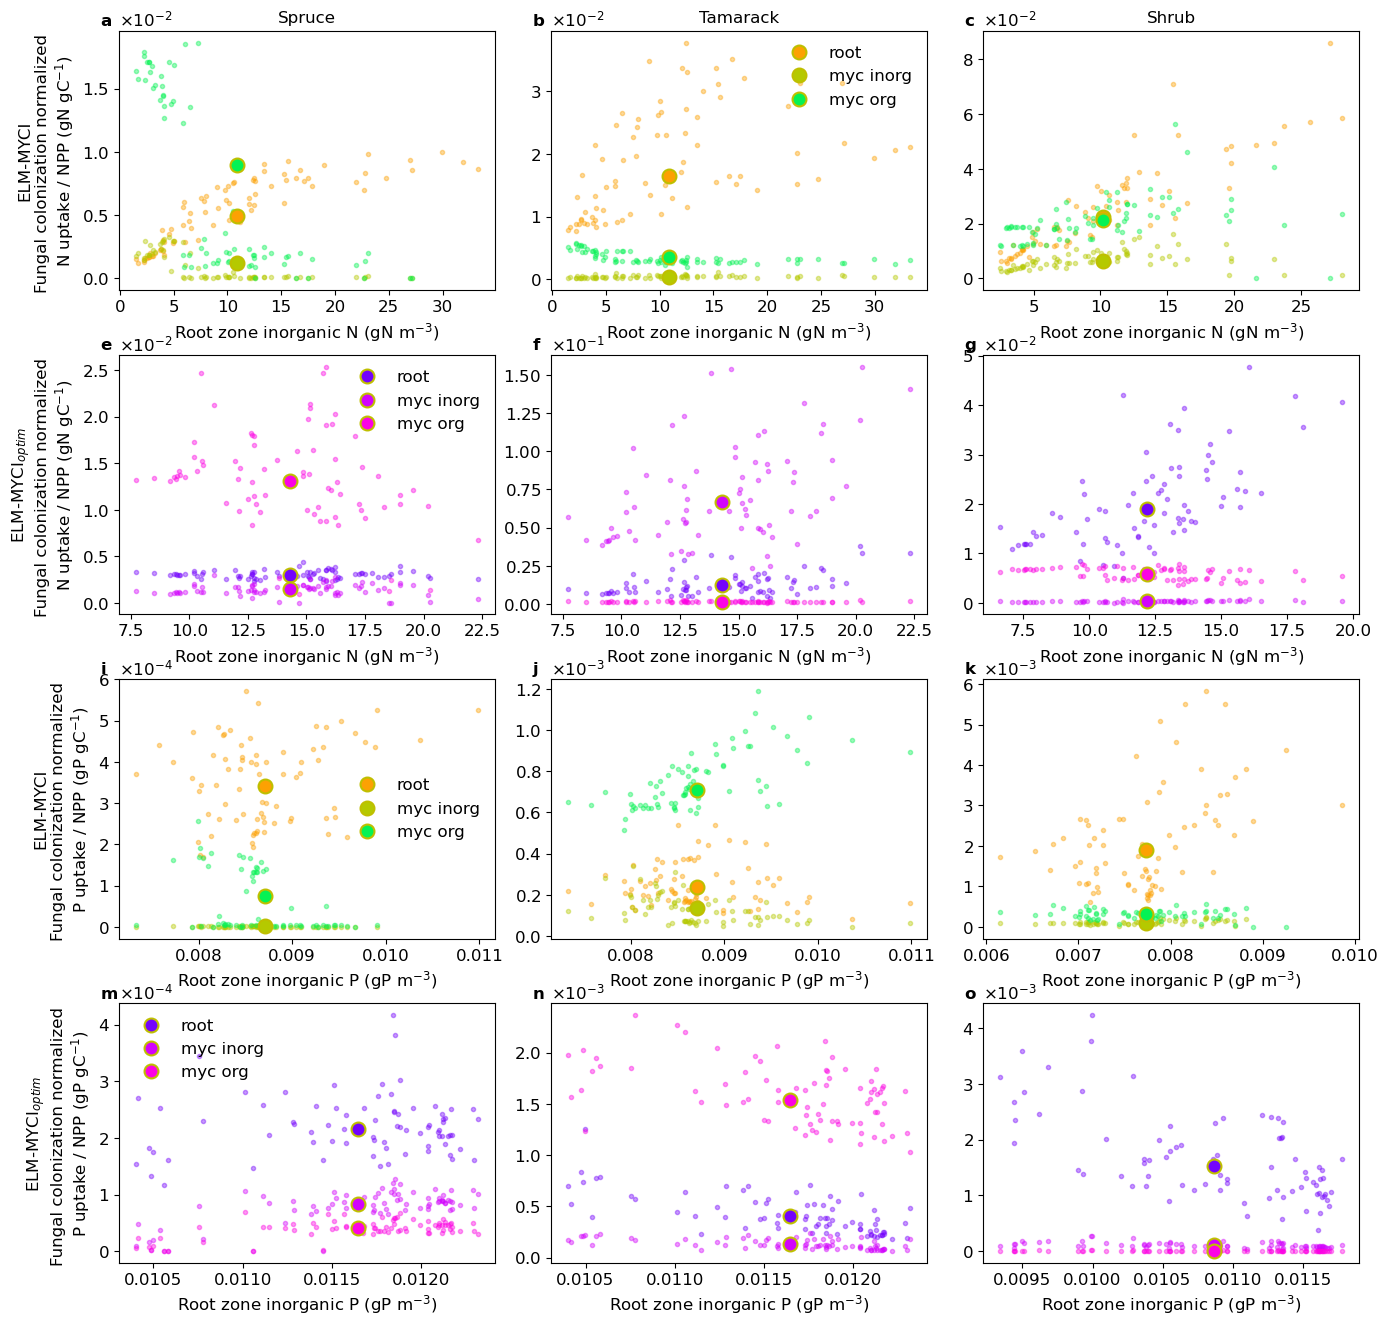

In [9]:
#########################################################################
# N&P uptake per unit GPP, across temperature and nutrient gradients
# separate out the mineral and organic nutrient uptakes
#########################################################################
fig, axes = plt.subplots(4, 3, figsize = (16, 16), sharex = False, sharey = False)
fig.subplots_adjust(hspace = 0.25, wspace = 0.15)

for n, nu in enumerate(['N','P']):
    if nu == 'N':
        nu_var = 'SMINN_vr_ROOTFR'
    else:
        nu_var = 'SOLUTIONP_vr_ROOTFR'

    for i, (pft,name) in enumerate(zip(['2','3','11'],['Spruce','Tamarack','Shrub'])):
        for p, (prefix, pname) in \
            enumerate(zip(['UQ_20240107', 'UQ_20240112'],  
                          ['ELM-MYCI', 'ELM-MYCI$_{optim}$'])):
            if p == 0:
                clist = ['#fca103', '#b5c900', '#05f254']
            else:
                clist = ['#7303fc', '#d203fc', '#fc03e3']

            ax = axes[n*2+p, i]

            # Soil mineral nutrients content
            sminn = collection_gs[prefix].loc[:, (slice(None), nu_var, pft)]
            sminn = sminn.resample('1Y').mean()
            sminn_mean = sminn.mean().mean()

            # Fungal inhibition rate
            inhib = collection_gs[prefix].loc[:, (slice(None), 'FUNGI_INHIB_PATCH', pft)]

            # Total mineral nutrients uptake
            smin_uptake = collection_gs[prefix].loc[:, (slice(None), 
                                                        f'SMIN{nu}_TO_{nu}POOL', pft)]

            # C assimilation
            cdemand = collection_gs[prefix].loc[:, (slice(None), 'AVAILC', pft)]

            # Direct fine root
            min_uptake_root = collection_gs[prefix].loc[:, (slice(None), 
                f'FROOT_{nu}DEMAND_POT', pft)] / collection_gs[prefix].loc[:, 
                (slice(None), f'PLANT_{nu}DEMAND_POT', pft)].values * smin_uptake.values / \
                (1 - inhib.values) # divide by fungal inhibition
            min_cpool_root = min_uptake_root.resample('1Y').mean() / \
                             cdemand.resample('1Y').mean().values
            min_cpool_root_mean = min_uptake_root.mean().mean() / cdemand.mean().mean()

            # Fungal mineral
            min_uptake_fungi = collection_gs[prefix].loc[:, (slice(None), 
                f'FUNGI_{nu}DEMAND_POT', pft)] / collection_gs[prefix].loc[:, 
                (slice(None), f'PLANT_{nu}DEMAND_POT', pft)].values * smin_uptake.values / \
                inhib.values # divide by fungal inhibition
            min_cpool_fungi = min_uptake_fungi.resample('1Y').mean() / \
                              cdemand.resample('1Y').mean().values
            min_cpool_fungi_mean = min_uptake_fungi.mean().mean() / cdemand.mean().mean()

            # Fungal organic
            sorg_uptake = collection_gs[prefix].loc[:, (slice(None), 
                f'FUNGI_SOM_TO_{nu}POOL', pft)] / inhib.values  # divide by fungal inhibition
            org_cpool = sorg_uptake.resample('1Y').mean() / \
                cdemand.resample('1Y').mean().values
            org_cpool_mean = sorg_uptake.mean().mean() / cdemand.mean().mean()

            # Draw
            ax.plot(sminn.values.reshape(-1), 
                        (min_cpool_root).values.reshape(-1), 'o',
                        color = clist[0], markersize = 3,
                        alpha = 0.4, zorder = 1)
            ax.plot(sminn_mean, min_cpool_root_mean, 'o',
                    color = clist[0], markersize = 10, markeredgecolor = 'y',
                    zorder = 3, markeredgewidth = 1.5, label = f'root')
            ax.plot(sminn.values.reshape(-1), 
                        (min_cpool_fungi).values.reshape(-1), 'o',
                        color = clist[1], markersize = 3,
                        alpha = 0.4, zorder = 1)
            ax.plot(sminn_mean, min_cpool_fungi_mean, 'o',
                    color = clist[1], markersize = 10, markeredgecolor = 'y',
                    zorder = 3, markeredgewidth = 1.5, label = f'myc inorg')
            ax.plot(sminn.values.reshape(-1), 
                        (org_cpool).values.reshape(-1), 'o',
                        color = clist[2], markersize = 3,
                        alpha = 0.4, zorder = 1)
            ax.plot(sminn_mean, org_cpool_mean, 'o', label = f'myc org', 
                    color = clist[2], markersize = 10, markeredgecolor = 'y',
                    zorder = 3, markeredgewidth = 1.5)

            if i == 0:
                if nu == 'N':
                    ax.set_ylabel(f'{pname}\nFungal colonization normalized \n{nu} uptake / NPP (g' + nu + ' gC$^{-1}$)')
                else:
                    ax.set_ylabel(f'{pname}\nFungal colonization normalized \n{nu} uptake / NPP (g' + nu + ' gC$^{-1}$)')

            if p == 0 and n == 0:
                ax.set_title(name)

            if nu == 'N':
                ax.set_xlabel(f'Root zone inorganic {nu} (g{nu} ' + 'm$^{-3}$)')
            else:
                ax.set_xlabel(f'Root zone inorganic {nu} (g' + f'{nu} ' + 'm$^{-3}$)')

            if p == 0:
                if nu == 'N':
                    if i == 1:
                        ax.legend(frameon = False)
                else:
                    if i == 0:
                        ax.legend(frameon = False)
            else:
                if i == 0:
                    ax.legend(frameon = False)

            #ax.set_xscale('log')
            # ax.set_yscale('log')
            ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
            ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ##if nu == 'P':
            ##    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
            ax.text(-0.05, 1.02, labs[n*8+p*4+i], 
                    fontdict = {'weight': 'bold'}, transform = ax.transAxes)